In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/wisam1985/iot-agriculture-2024/IoTProcessed_Data.csv


In [2]:
import pandas as pd

# =========================
# 1. Load Data
# =========================
data = pd.read_csv('/kaggle/input/datasets/wisam1985/iot-agriculture-2024/IoTProcessed_Data.csv')

# Clean column names (removes spaces)
data.columns = data.columns.str.strip()

print("Columns in dataset:\n", data.columns.tolist())

# =========================
# 2. Select Target Column
# =========================
# 👉 CHANGE THIS to your actual target if needed
target = data.columns[-1]   # automatically picks last column

print("\nSelected target column:", target)

X = data.drop(target, axis=1)
y = data[target]

# =========================
# 3. Handle Non-Numeric Data
# =========================
X = pd.get_dummies(X, drop_first=True)

# =========================
# 4. Train-Test Split
# =========================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 5. Detect Problem Type
# =========================
if y.dtype == 'object' or len(y.unique()) < 10:
    problem_type = "classification"
else:
    problem_type = "regression"

print("Problem type detected:", problem_type)

# =========================
# 6. Train Models
# =========================
if problem_type == "regression":
    from sklearn.linear_model import LinearRegression
    from sklearn.tree import DecisionTreeRegressor
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.metrics import mean_squared_error, r2_score

    models = {
        "Linear Regression": LinearRegression(),
        "Decision Tree": DecisionTreeRegressor(random_state=42),
        "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
    }

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        print(f"\n{name}")
        print("MSE:", mean_squared_error(y_test, y_pred))
        print("R2 Score:", r2_score(y_test, y_pred))

else:
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import accuracy_score, classification_report

    models = {
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
    }

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        print(f"\n{name}")
        print("Accuracy:", accuracy_score(y_test, y_pred))
        print(classification_report(y_test, y_pred))

Columns in dataset:
 ['date', 'tempreature', 'humidity', 'water_level', 'N', 'P', 'K', 'Fan_actuator_OFF', 'Fan_actuator_ON', 'Watering_plant_pump_OFF', 'Watering_plant_pump_ON', 'Water_pump_actuator_OFF', 'Water_pump_actuator_ON']

Selected target column: Water_pump_actuator_ON
Problem type detected: classification

Decision Tree
Accuracy: 1.0
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      5883
         1.0       1.00      1.00      1.00      1702

    accuracy                           1.00      7585
   macro avg       1.00      1.00      1.00      7585
weighted avg       1.00      1.00      1.00      7585


Random Forest
Accuracy: 0.9998681608437706
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      5883
         1.0       1.00      1.00      1.00      1702

    accuracy                           1.00      7585
   macro avg       1.00      1.00      1.00      7585
weighted a

Columns:
 ['date', 'tempreature', 'humidity', 'water_level', 'N', 'P', 'K', 'Fan_actuator_OFF', 'Fan_actuator_ON', 'Watering_plant_pump_OFF', 'Watering_plant_pump_ON', 'Water_pump_actuator_OFF', 'Water_pump_actuator_ON']

===== Decision Tree =====


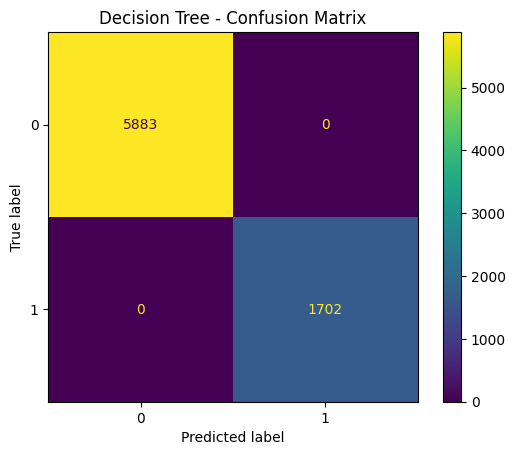


===== Random Forest =====


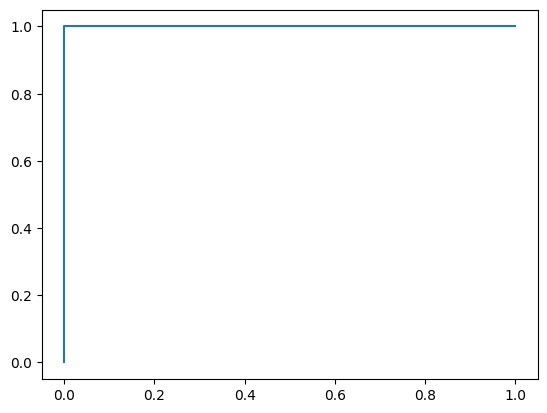

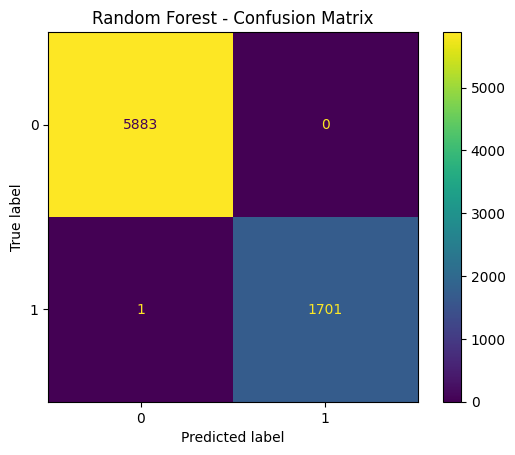

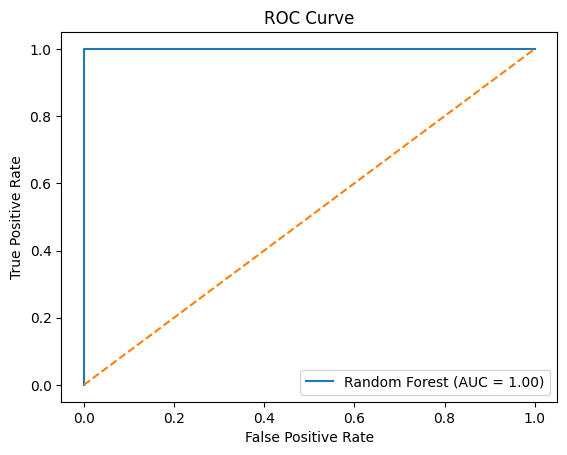

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. Load Data
# =========================
data = pd.read_csv('/kaggle/input/datasets/wisam1985/iot-agriculture-2024/IoTProcessed_Data.csv')

# Clean column names
data.columns = data.columns.str.strip()

print("Columns:\n", data.columns.tolist())

# =========================
# 2. Select Target
# =========================
target = data.columns[-1]   # ⚠️ Change if needed
X = data.drop(target, axis=1)
y = data[target]

# Convert categorical features
X = pd.get_dummies(X, drop_first=True)

# =========================
# 3. Train-Test Split
# =========================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 4. Models
# =========================
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# =========================
# 5. Evaluation
# =========================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc

for name, model in models.items():
    print(f"\n===== {name} =====")

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # -------------------------
    # Confusion Matrix
    # -------------------------
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"{name} - Confusion Matrix")
    plt.show()

    # -------------------------
    # ROC Curve (Binary Only)
    # -------------------------
    if len(y.unique()) == 2:
        y_prob = model.predict_proba(X_test)[:, 1]

        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# Plot ROC curve (combined)
if len(y.unique()) == 2:
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()